# Gráficas principales de la base de violencia

Este cuaderno reúne 15 consultas relevantes del proyecto y las convierte en gráficas simples de leer. La idea es priorizar salidas que ayuden a ver tendencia, concentración territorial, comparaciones y cruces entre violencia y salud.

In [24]:
from pathlib import Path
import subprocess
import tempfile
import warnings

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=UserWarning)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

DB_PATH = "localhost:/Users/wilsonjonatan/Documents/bases 1 2026/violencia guate/sql/db/violencia_guate.fdb"
DB_USER = "sysdba"
DB_PASSWORD = "masterkey"
ISQL_PATH = "/Library/Frameworks/Firebird.framework/Resources/bin/isql"


def run_query(sql: str) -> pd.DataFrame:
    query = sql.strip().rstrip(";") + ";"
    script = f"SET HEADING OFF;\nSET LIST ON;\n{query}\n"
    with tempfile.NamedTemporaryFile("w", suffix=".sql", delete=False, encoding="utf-8") as tmp:
        tmp.write(script)
        tmp_path = tmp.name
    try:
        result = subprocess.run(
            [ISQL_PATH, "-user", DB_USER, "-password", DB_PASSWORD, DB_PATH, "-q", "-i", tmp_path],
            capture_output=True,
            text=True,
        )
    finally:
        Path(tmp_path).unlink(missing_ok=True)

    output = "\n".join(part for part in (result.stdout, result.stderr) if part)
    rows = []
    current = {}
    for raw_line in output.splitlines():
        line = raw_line.strip()
        if not line:
            if current:
                rows.append(current)
                current = {}
            continue
        if line.startswith("SQL>") or line.startswith("DatabaseError") or line.startswith("Warning"):
            continue
        parts = line.split(None, 1)
        if len(parts) == 2:
            key, value = parts
            current[key.lower()] = value.strip()
    if current:
        rows.append(current)

    df = pd.DataFrame(rows)
    for column in df.columns:
        numeric = pd.to_numeric(df[column], errors="coerce")
        if numeric.notna().all() and len(df[column]) > 0:
            df[column] = numeric
    return df


def plot_bar(df, x, y, title, horizontal=False, color="#2a6f97", rotate=45):
    if df.empty:
        print("Sin datos para graficar.")
        return
    plt.figure(figsize=(12, 6))
    if horizontal:
        sns.barplot(data=df, x=y, y=x, color=color)
        plt.ylabel(x)
        plt.xlabel(y)
    else:
        sns.barplot(data=df, x=x, y=y, color=color)
        plt.xticks(rotation=rotate, ha="right")
        plt.xlabel(x)
        plt.ylabel(y)
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_line(df, x, y, hue=None, title=""):
    if df.empty:
        print("Sin datos para graficar.")
        return
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=df, x=x, y=y, hue=hue, marker="o")
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_heatmap(df, index, columns, values, title=""):
    if df.empty:
        print("Sin datos para graficar.")
        return
    pivot = df.pivot(index=index, columns=columns, values=values).fillna(0)
    pivot = pivot.apply(pd.to_numeric, errors="coerce").fillna(0)
    plt.figure(figsize=(12, 7))
    sns.heatmap(pivot, cmap="Blues", linewidths=.5)
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_donut(df, labels, values, title=""):
    if df.empty:
        print("Sin datos para graficar.")
        return
    plt.figure(figsize=(8, 8))
    plt.pie(df[values], labels=df[labels], autopct="%1.1f%%", startangle=90, wedgeprops={"width": 0.4})
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_hist(df, column, title="", bins=20):
    if df.empty:
        print("Sin datos para graficar.")
        return
    plt.figure(figsize=(12, 6))
    sns.histplot(df[column].dropna(), bins=bins, kde=True, color="#457b9d")
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_scatter(df, x, y, title=""):
    if df.empty:
        print("Sin datos para graficar.")
        return
    plt.figure(figsize=(10, 6))
    sns.regplot(data=df, x=x, y=y, scatter_kws={"alpha": 0.7}, line_kws={"color": "crimson"})
    plt.title(title)
    plt.tight_layout()
    plt.show()

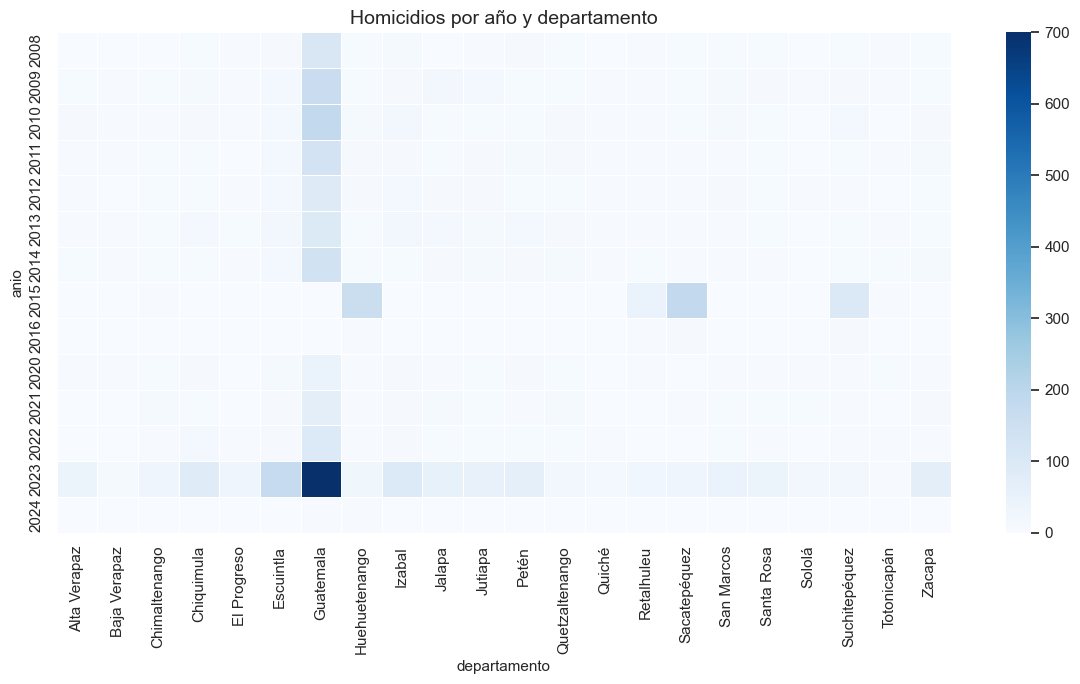

In [25]:
# 1. Homicidios por año y departamento
sql = """
SELECT
    EXTRACT(YEAR FROM h.fecha_hecho) AS anio,
    d.nombre AS departamento,
    COUNT(*) AS total_homicidios
FROM hecho_delictivo hd
JOIN hecho h ON h.id_hecho = hd.id_hecho
JOIN ubicacion u ON u.id_ubicacion = h.id_ubicacion
JOIN municipio m ON m.id_municipio = u.id_municipio
JOIN departamento d ON d.id_departamento = m.id_departamento
JOIN delito_cometido dc ON dc.id_delito_cometido = hd.id_delito
JOIN delito de ON de.id_delito = dc.id_tipo_delito
WHERE de.nombre CONTAINING 'HOMICIDIO'
GROUP BY 1, 2
ORDER BY 1, 2
"""
df = run_query(sql)
if df.empty:
    print("No hay datos de homicidios todavía.")
else:
    plot_heatmap(df, "anio", "departamento", "total_homicidios", "Homicidios por año y departamento")

In [26]:
# 2. Denuncias por violencia contra la mujer por departamento
sql = """
SELECT FIRST 15
    d.nombre AS departamento,
    COUNT(*) AS total_denuncias
FROM denuncia dn
JOIN hecho h ON h.id_hecho = dn.id_hecho
JOIN tipo_hecho th ON th.id_tipo_hecho = h.id_tipo_hecho
JOIN ubicacion u ON u.id_ubicacion = h.id_ubicacion
JOIN municipio m ON m.id_municipio = u.id_municipio
JOIN departamento d ON d.id_departamento = m.id_departamento
WHERE th.nombre CONTAINING 'MUJER'
   OR th.nombre CONTAINING 'VIOLENCIA CONTRA LA MUJER'
   OR th.nombre CONTAINING 'VCM'
GROUP BY 1
ORDER BY total_denuncias DESC
"""
df = run_query(sql)
plot_bar(df, "departamento", "total_denuncias", "Denuncias por violencia contra la mujer por departamento", horizontal=True)

Sin datos para graficar.


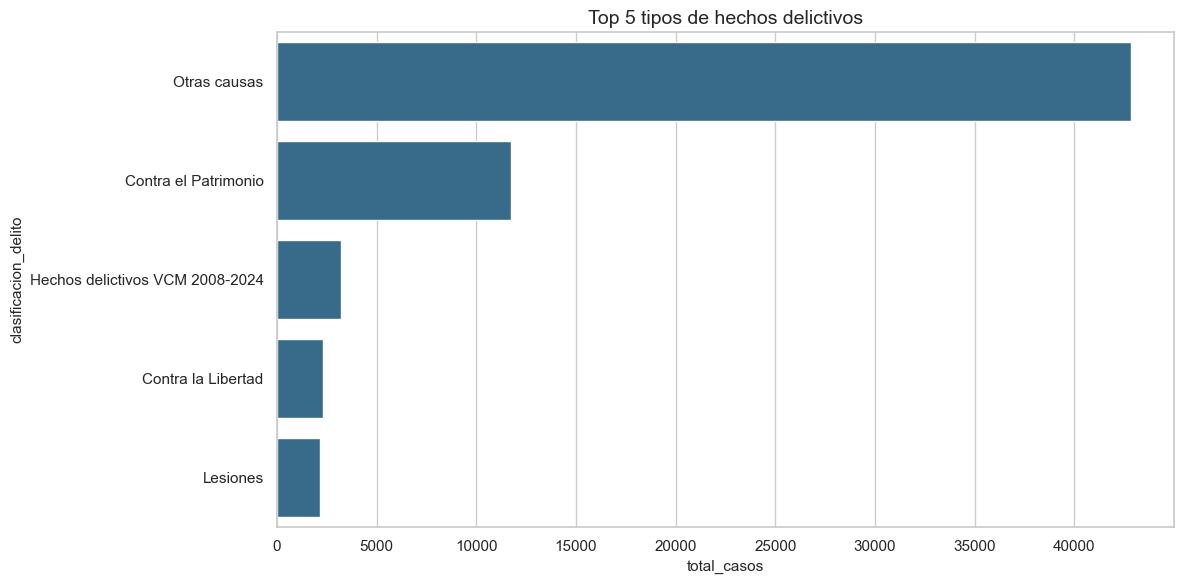

In [27]:
# 3. Top 5 tipos de hechos delictivos en los ultimos 5 anios
sql = """
SELECT FIRST 5
    cd.nombre AS clasificacion_delito,
    COUNT(*) AS total_casos
FROM hecho_delictivo hd
JOIN hecho h ON h.id_hecho = hd.id_hecho
JOIN delito_cometido dc ON dc.id_delito_cometido = hd.id_delito
JOIN clasificacion_delito cd ON cd.id_clasificacion_delito = dc.id_clasificacion_delito
WHERE h.fecha_hecho >= DATEADD(-5 YEAR TO CURRENT_DATE)
GROUP BY 1
ORDER BY total_casos DESC
"""
df = run_query(sql)
plot_bar(df, "clasificacion_delito", "total_casos", "Top 5 tipos de hechos delictivos", horizontal=True)

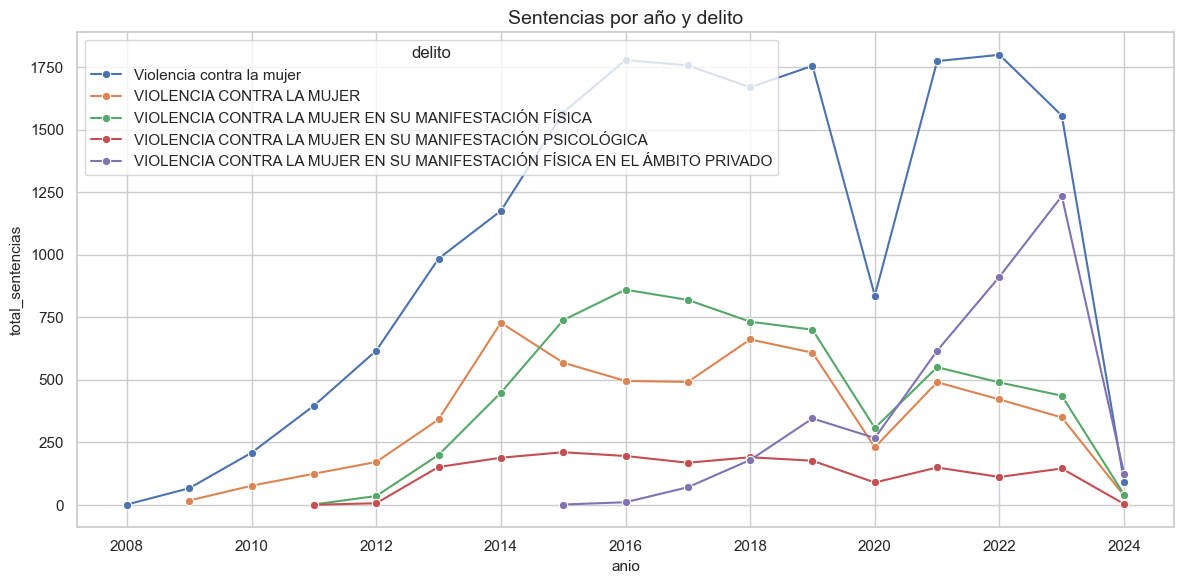

In [28]:
# 4. Sentencias por anio y tipo de delito
sql = """
SELECT
    EXTRACT(YEAR FROM s.fecha_sentencia) AS anio,
    COALESCE(de.nombre, 'SIN_DELITO') AS delito,
    COUNT(*) AS total_sentencias
FROM sentencia s
LEFT JOIN delito de ON de.id_delito = s.id_delito
WHERE s.fecha_sentencia IS NOT NULL
GROUP BY 1, 2
ORDER BY 1, 2
"""
df = run_query(sql)
if not df.empty:
    top_delitos = (
        df.groupby("delito", as_index=False)["total_sentencias"].sum()
        .sort_values("total_sentencias", ascending=False)
        .head(5)["delito"]
    )
    df = df[df["delito"].isin(top_delitos)]
    plot_line(df, "anio", "total_sentencias", hue="delito", title="Sentencias por año y delito")
else:
    print("No hay datos de sentencias.")

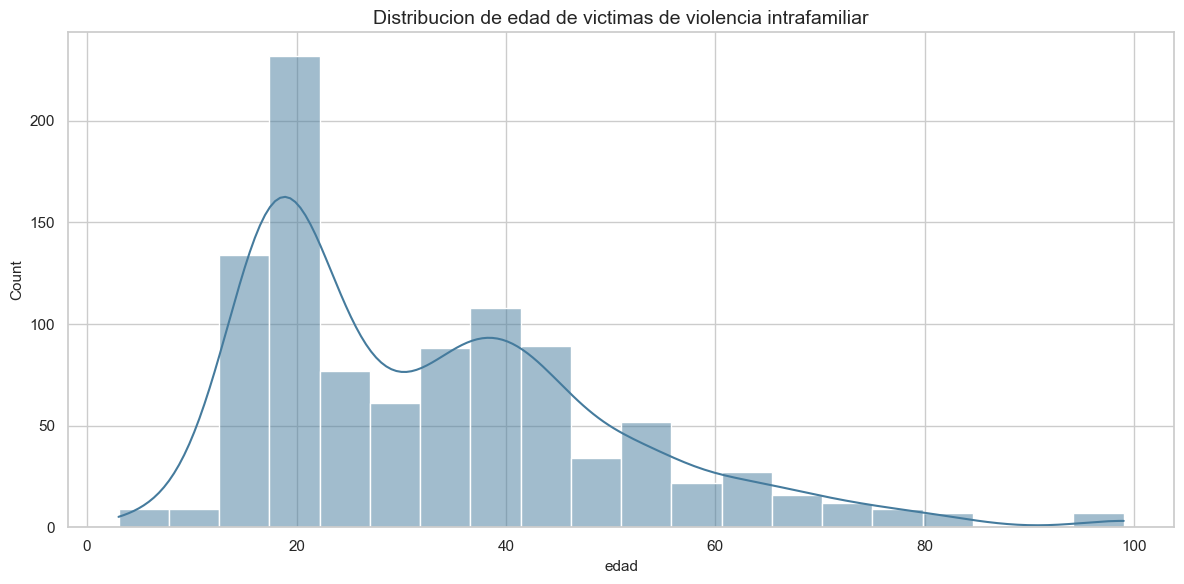

In [29]:
# 5. Distribucion de edad de victimas de violencia intrafamiliar
sql = """
SELECT
    DATEDIFF(YEAR FROM p.fecha_nacimiento TO h.fecha_hecho) AS edad
FROM caso_violencia_intrafamiliar cvi
JOIN hecho h ON h.id_hecho = cvi.id_hecho
JOIN persona p ON p.id_persona = cvi.id_victima
WHERE p.fecha_nacimiento IS NOT NULL
  AND h.fecha_hecho IS NOT NULL
  AND DATEDIFF(YEAR FROM p.fecha_nacimiento TO h.fecha_hecho) BETWEEN 0 AND 100
"""
df = run_query(sql)
plot_hist(df, "edad", "Distribucion de edad de victimas de violencia intrafamiliar", bins=20)

In [30]:
# 6. Embarazos adolescentes por departamento
sql = """
SELECT
    d.nombre AS departamento,
    COUNT(*) AS total_embarazos_adolescentes
FROM embarazo_adolescente ea
JOIN hecho h ON h.id_hecho = ea.id_hecho
JOIN ubicacion u ON u.id_ubicacion = h.id_ubicacion
JOIN municipio m ON m.id_municipio = u.id_municipio
JOIN departamento d ON d.id_departamento = m.id_departamento
WHERE ea.edad_gestante < 19
GROUP BY 1
ORDER BY total_embarazos_adolescentes DESC
"""
df = run_query(sql)
plot_bar(df, "departamento", "total_embarazos_adolescentes", "Embarazos adolescentes por departamento", horizontal=True)

Sin datos para graficar.


In [31]:
# 7. Casos de violencia infantil relacionados con trabajo infantil por sector economico
sql = """
SELECT
    COALESCE(se.nombre, 'SIN_SECTOR') AS sector_economico,
    COUNT(*) AS total_casos
FROM caso_violencia_ninez cvn
LEFT JOIN caso_ninez_trabajo_infantil cnti ON cnti.id_caso_violencia_ninez = cvn.id_caso_violencia_ninez
LEFT JOIN sector_economico se ON se.id_sector_economico = cnti.id_sector_economico
WHERE COALESCE(cvn.relacionado_trabajo_infantil, 0) = 1
   OR cnti.id_caso_ninez_trabajo_infantil IS NOT NULL
GROUP BY 1
ORDER BY total_casos DESC
"""
df = run_query(sql)
plot_bar(df, "sector_economico", "total_casos", "Violencia infantil relacionada con trabajo infantil", horizontal=True)

Sin datos para graficar.


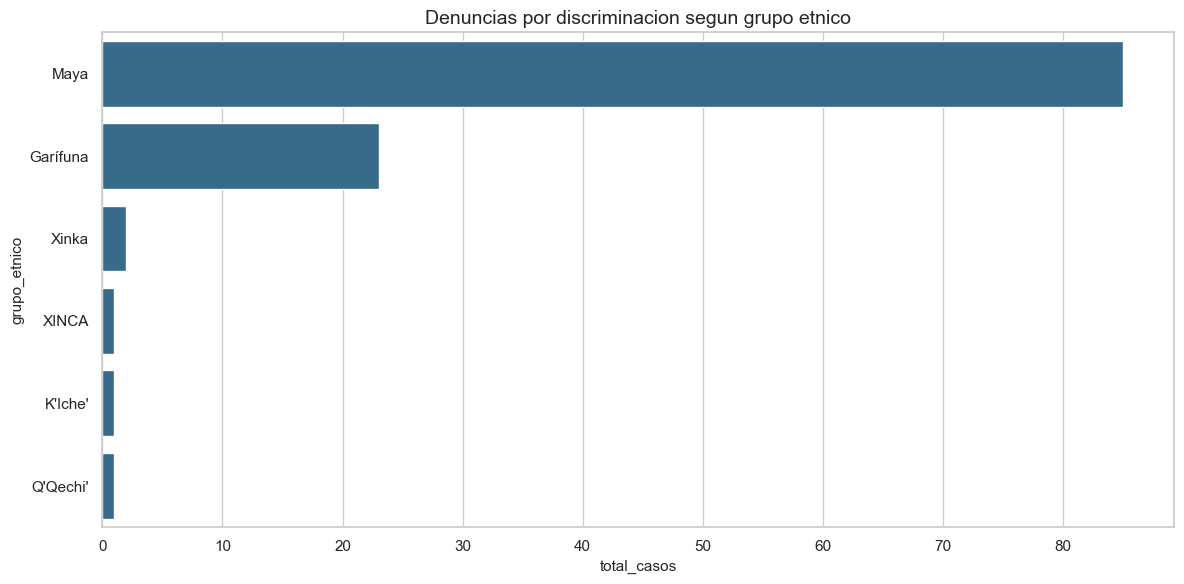

In [32]:
# 8. Denuncias por discriminacion segun grupo etnico
sql = """
SELECT
    COALESCE(ge.nombre, 'SIN_GRUPO') AS grupo_etnico,
    COUNT(*) AS total_casos
FROM violencia_estructural ve
JOIN persona p ON p.id_persona = ve.id_victima
LEFT JOIN grupo_etnico ge ON ge.id_grupo_etnico = p.id_grupo_etnico
GROUP BY 1
ORDER BY total_casos DESC
"""
df = run_query(sql)
plot_bar(df, "grupo_etnico", "total_casos", "Denuncias por discriminacion segun grupo etnico", horizontal=True)

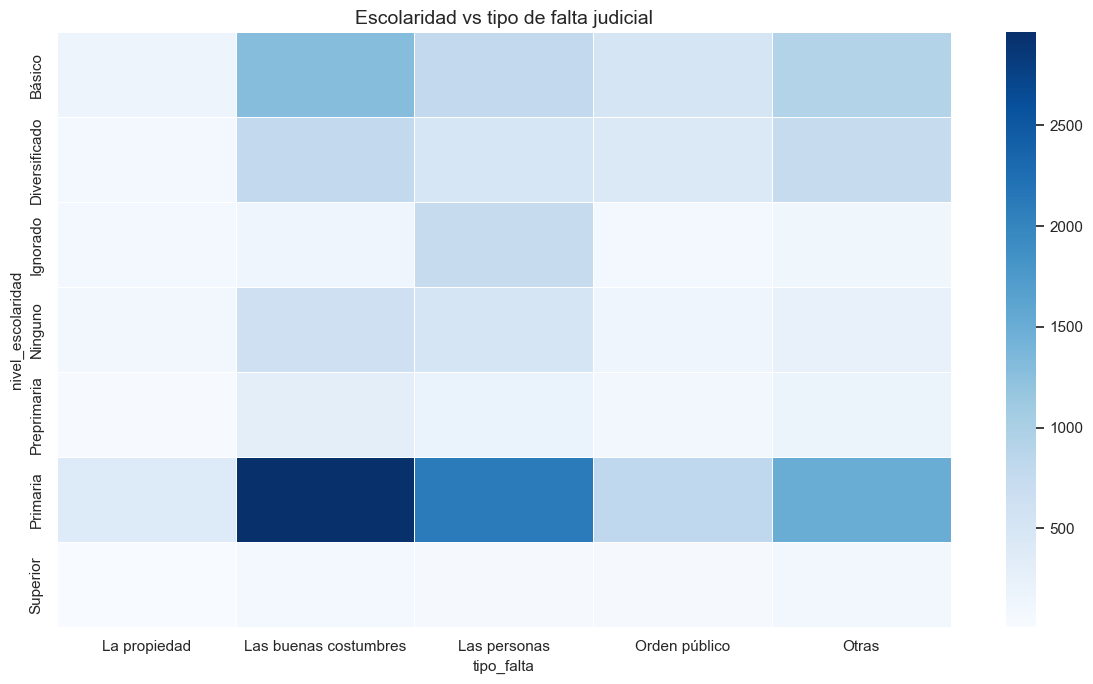

In [33]:
# 9. Escolaridad vs tipo de falta judicial
sql = """
SELECT
    COALESCE(ne.nombre, 'SIN_ESCOLARIDAD') AS nivel_escolaridad,
    COALESCE(tf.nombre, 'SIN_TIPO_FALTA') AS tipo_falta,
    COUNT(*) AS total_casos
FROM falta f
JOIN hecho h ON h.id_hecho = f.id_hecho
JOIN tipo_falta tf ON tf.id_tipo_falta = f.id_tipo_falta
JOIN involucrado_hecho ih ON ih.id_hecho = h.id_hecho
JOIN persona p ON p.id_persona = ih.id_involucrado
LEFT JOIN nivel_escolaridad ne ON ne.id_nivel_escolaridad = p.id_nivel_escolaridad
GROUP BY 1, 2
ORDER BY 1, 2
"""
df = run_query(sql)
if not df.empty:
    plot_heatmap(df, "nivel_escolaridad", "tipo_falta", "total_casos", "Escolaridad vs tipo de falta judicial")
else:
    print("No hay datos de faltas judiciales.")

In [34]:
# 10. Numero de necropsias por anio
sql = """
SELECT
    EXTRACT(YEAR FROM h.fecha_hecho) AS anio,
    COUNT(*) AS total_necropsias
FROM necropsia n
JOIN hecho h ON h.id_hecho = n.id_hecho
WHERE h.fecha_hecho IS NOT NULL
GROUP BY 1
ORDER BY 1
"""
df = run_query(sql)
plot_line(df, "anio", "total_necropsias", "Numero de necropsias por anio")

Sin datos para graficar.


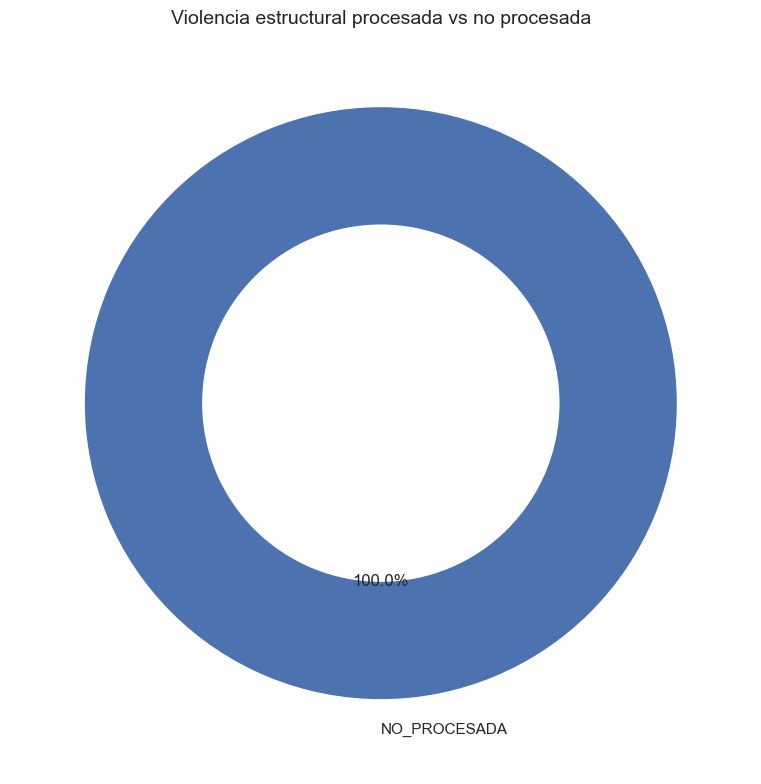

In [35]:
# 11. Violencia estructural procesada vs no procesada
sql = """
SELECT
    CASE COALESCE(vp.es_procesada, 0)
        WHEN 1 THEN 'PROCESADA'
        ELSE 'NO_PROCESADA'
    END AS estado_proceso,
    COUNT(*) AS total_casos
FROM vw_violencia_estructural_proceso vp
GROUP BY 1
ORDER BY total_casos DESC
"""
df = run_query(sql)
plot_donut(df, "estado_proceso", "total_casos", "Violencia estructural procesada vs no procesada")

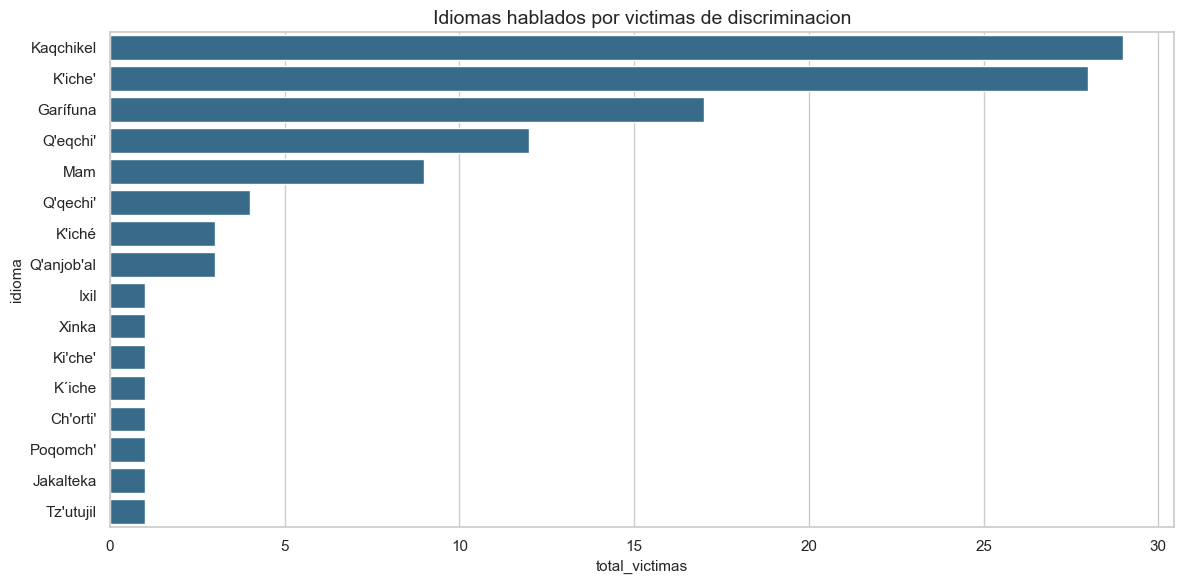

In [36]:
# 12. Idiomas hablados por victimas de discriminacion
sql = """
SELECT
    COALESCE(il.nombre, 'SIN_IDIOMA') AS idioma,
    COUNT(*) AS total_victimas
FROM violencia_estructural ve
JOIN idioma_persona ip ON ip.id_persona = ve.id_victima
JOIN idioma_lengua il ON il.id_lengua = ip.id_lengua
GROUP BY 1
ORDER BY total_victimas DESC
"""
df = run_query(sql)
plot_bar(df, "idioma", "total_victimas", "Idiomas hablados por victimas de discriminacion", horizontal=True)

In [37]:
# 13. Personas por hogar en casos VIF
sql = """
SELECT
    cvh.id_caso_violencia_intrafamiliar,
    cvh.id_hogar,
    COUNT(DISTINCT ph.id_persona) AS total_personas_hogar
FROM caso_vif_hogar cvh
LEFT JOIN persona_hogar ph ON ph.id_hogar = cvh.id_hogar
GROUP BY 1, 2
ORDER BY total_personas_hogar DESC
"""
df = run_query(sql)
plot_hist(df, "total_personas_hogar", "Personas por hogar en casos de violencia intrafamiliar", bins=15)

Sin datos para graficar.


In [38]:
# 14. Desnutricion aguda por departamento y anio
sql = """
SELECT
    vt.anio_registro AS anio,
    vt.departamento,
    SUM(vt.casos) AS total_casos
FROM vw_registro_salud_territorial vt
WHERE vt.indicador_salud CONTAINING 'DESNUTRICION AGUDA'
GROUP BY 1, 2
ORDER BY 1, total_casos DESC
"""
df = run_query(sql)
if not df.empty:
    top_departamentos = (
        df.groupby("departamento", as_index=False)["total_casos"].sum()
        .sort_values("total_casos", ascending=False)
        .head(5)["departamento"]
    )
    df = df[df["departamento"].isin(top_departamentos)]
    plot_line(df, "anio", "total_casos", hue="departamento", title="Desnutricion aguda por departamento y anio")
else:
    print("No hay datos de desnutricion aguda.")

No hay datos de desnutricion aguda.


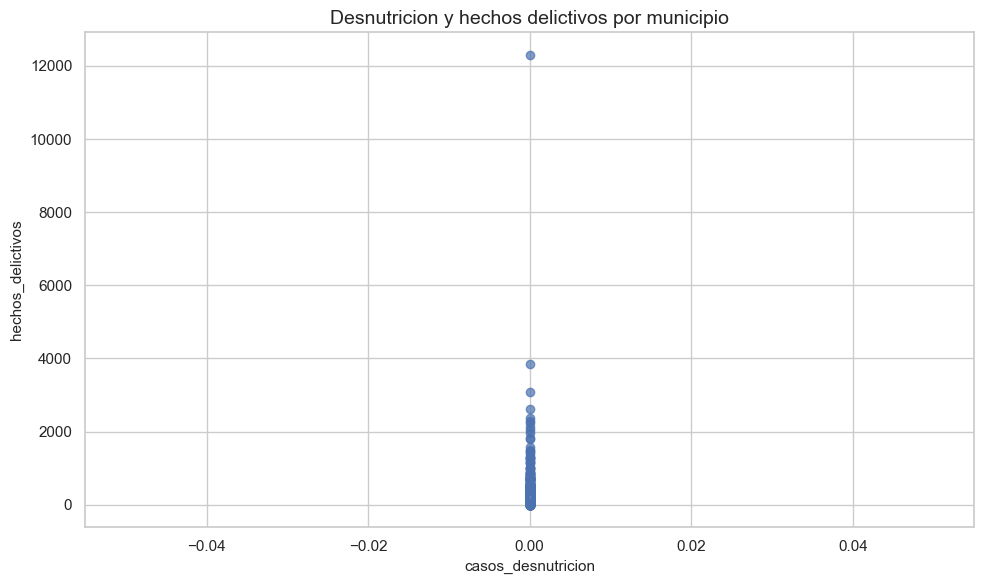

In [39]:
# 15. Desnutricion y hechos delictivos por municipio
sql = """
WITH salud AS (
    SELECT
        vt.anio_registro AS anio,
        vt.departamento,
        vt.municipio,
        SUM(vt.casos) AS casos_desnutricion
    FROM vw_registro_salud_territorial vt
    WHERE vt.indicador_salud CONTAINING 'DESNUTRICION'
    GROUP BY 1, 2, 3
),
delitos AS (
    SELECT
        EXTRACT(YEAR FROM h.fecha_hecho) AS anio,
        d.nombre AS departamento,
        m.nombre AS municipio,
        COUNT(*) AS hechos_delictivos
    FROM hecho_delictivo hd
    JOIN hecho h ON h.id_hecho = hd.id_hecho
    JOIN ubicacion u ON u.id_ubicacion = h.id_ubicacion
    JOIN municipio m ON m.id_municipio = u.id_municipio
    JOIN departamento d ON d.id_departamento = m.id_departamento
    GROUP BY 1, 2, 3
)
SELECT
    COALESCE(s.anio, d.anio) AS anio,
    COALESCE(s.departamento, d.departamento) AS departamento,
    COALESCE(s.municipio, d.municipio) AS municipio,
    COALESCE(s.casos_desnutricion, 0) AS casos_desnutricion,
    COALESCE(d.hechos_delictivos, 0) AS hechos_delictivos
FROM salud s
FULL JOIN delitos d
  ON d.anio = s.anio
 AND d.departamento = s.departamento
 AND d.municipio = s.municipio
ORDER BY 1, 2, 3
"""
df = run_query(sql)
if df.empty:
    print("No hay datos suficientes para la comparacion salud-violencia.")
else:
    df["ratio"] = df["hechos_delictivos"] / df["casos_desnutricion"].replace(0, pd.NA)
    plot_scatter(df.dropna(subset=["casos_desnutricion", "hechos_delictivos"]), "casos_desnutricion", "hechos_delictivos", "Desnutricion y hechos delictivos por municipio")